In [1]:
# basic imports
import numpy as np
import matplotlib.pyplot as plt
import math
import pathlib
import random
import sklearn.linear_model
import torch
import torch.nn as nn
from torch.nn.modules.transformer import MultiheadAttention
from torch.optim.lr_scheduler import LambdaLR

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", device)
else:
    device = torch.device("cpu")
    print("No GPU -> using CPU:", device)

import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

No GPU -> using CPU: cpu


**Data Generating Prior** | Ridge Regression Prior

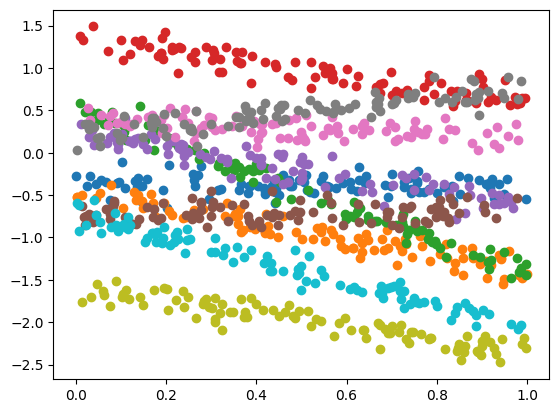

In [2]:
num_datasets = 10
num_points_in_each_dataset = 100
hyperparameters = {
    'variance_weights': 1.0,
    'output_noise': 0.1,
}
num_features = 1

def get_ridge_regression_prior(num_datasets, num_features, num_points_in_each_dataset, hyperparameters, bias_term=True):
    """
    Args:
        num_datasets: number of datasets in each batch
        num_features: number of features to use
        num_points_in_each_dataset: number of points in each dataset
        hyperparameters: hyperparameters to define the prior
        bias_term: Whether to use the bias term in the regression

    Returns:
        x, y
    """

    # Sample weights for ridge regression
    ws = torch.distributions.Normal(torch.zeros(num_features + 1 * bias_term), hyperparameters['variance_weights']).sample((num_datasets,)) # a tensor of shape (num_datasets, 1)

    # Sample xs
    xs_ = xs = torch.rand(num_datasets, num_points_in_each_dataset, num_features)
    if bias_term:
        xs_ = torch.cat([xs, torch.ones(num_datasets, num_points_in_each_dataset, 1)], 2)


    # Compute the conditional expectation for each x
    ys = torch.distributions.Normal(torch.einsum('nmf, nf -> nm', xs_, ws), hyperparameters['output_noise']).sample()

    return xs, ys

xs, ys = get_ridge_regression_prior(num_datasets, num_features, num_points_in_each_dataset, hyperparameters)
for dataset_index in range(num_datasets):
    plt.scatter(xs[dataset_index,:,0].numpy(), ys[dataset_index].numpy())

**Dataloader**

In [3]:
class PriorDataLoader(object):
    def __init__(self, get_prior_data_fn, batch_size, num_points_in_each_dataset):
        self.batch_size = batch_size
        self.num_points_in_each_dataset = num_points_in_each_dataset
        self.get_prior_data_fn = get_prior_data_fn

        self.epoch = 0

    def get_batch(self, train = True, batch_size=None):
        """
        Returns:
            xs, ys, trainset_size
        """
        self.epoch += train
        bs = batch_size if batch_size else self.batch_size
        return self.get_prior_data_fn(bs, self.num_points_in_each_dataset), self._sample_trainset_size()

    def _sample_trainset_size(self):
        # samples a number between 1 and n-1 with higher weights to larger numbers
        # Appendix E.1 of Muller et al. (2021)
        min_samples = 1
        max_samples = self.num_points_in_each_dataset - 1

        sampling_weights = [1 / (max_samples - min_samples - i) for i in range(max_samples - min_samples)]
        return random.choices(range(min_samples, max_samples), sampling_weights)[0]

In [4]:
get_prior_data_fn = lambda x, y: get_ridge_regression_prior(x, num_features, y, hyperparameters)
dl = PriorDataLoader(get_prior_data_fn, 10, 100)
for _ in range(2):
    (x,y), sz = dl.get_batch()

**Regression as Classification**

In [5]:
_, ys = get_ridge_regression_prior(100000, num_features, 100, hyperparameters)

def get_bucket_limits(num_outputs, ys):
    """
    Creates buckets based on the values in y.

    Args:
        num_outputs: number of buckets to create
        ys: values of y in the prior

    Returns:
        bucket_limits: An array containing the borders for each bucket.
    """
    ys  = ys.flatten()

    if len(ys) % num_outputs:
        ys = ys[:-(len(ys) % num_outputs)]

    ys_per_bucket = len(ys) // num_outputs
    full_range = (ys.min(), ys.max())

    ys_sorted, _ = ys.sort(0)

    bucket_limits = (ys_sorted[ys_per_bucket-1::ys_per_bucket][:-1] + ys_sorted[ys_per_bucket::ys_per_bucket]) / 2
    bucket_limits = torch.cat([full_range[0].unsqueeze(0), bucket_limits, full_range[1].unsqueeze(0)], dim=0)
    return bucket_limits

bl = get_bucket_limits(100, ys)
print(bl)
print(bl.shape)

tensor([-6.6097e+00, -2.7155e+00, -2.3793e+00, -2.1733e+00, -2.0206e+00,
        -1.8970e+00, -1.7922e+00, -1.6999e+00, -1.6170e+00, -1.5416e+00,
        -1.4718e+00, -1.4074e+00, -1.3470e+00, -1.2902e+00, -1.2363e+00,
        -1.1853e+00, -1.1364e+00, -1.0894e+00, -1.0444e+00, -1.0008e+00,
        -9.5855e-01, -9.1772e-01, -8.7785e-01, -8.3905e-01, -8.0124e-01,
        -7.6436e-01, -7.2836e-01, -6.9299e-01, -6.5849e-01, -6.2464e-01,
        -5.9135e-01, -5.5869e-01, -5.2655e-01, -4.9473e-01, -4.6348e-01,
        -4.3254e-01, -4.0207e-01, -3.7180e-01, -3.4196e-01, -3.1218e-01,
        -2.8269e-01, -2.5338e-01, -2.2444e-01, -1.9559e-01, -1.6672e-01,
        -1.3812e-01, -1.0942e-01, -8.0747e-02, -5.2292e-02, -2.3599e-02,
         4.9354e-03,  3.3547e-02,  6.2167e-02,  9.0790e-02,  1.1949e-01,
         1.4830e-01,  1.7709e-01,  2.0607e-01,  2.3487e-01,  2.6402e-01,
         2.9347e-01,  3.2289e-01,  3.5251e-01,  3.8241e-01,  4.1269e-01,
         4.4311e-01,  4.7407e-01,  5.0528e-01,  5.3

In [6]:
def y_to_bucket_idx(ys, bl):
    """
    Maps the value of y to the corresponding bucket in `bl`

    Args:
        ys: value of y to be mapped into a bucket in bl
        bl: bucket limits specifiying the borders of buckets

    Returns:
        values of corresponding bucket number for y in bl
    """
    target_sample = torch.searchsorted(bl, ys) - 1
    target_sample[ys <= bl[0]] = 0
    target_sample[ys >= bl[-1]] = len(bl) - 1 - 1
    return target_sample

target = y_to_bucket_idx(ys, bl)
print(target, ys.shape, target.shape, target.min(), target.max())

tensor([[88, 89, 91,  ..., 89, 93, 90],
        [39, 40, 63,  ..., 61, 74, 63],
        [29, 25, 34,  ..., 31, 27, 22],
        ...,
        [41, 39, 28,  ..., 49, 31, 25],
        [79, 55, 60,  ..., 78, 57, 55],
        [35, 42, 38,  ..., 36, 32, 43]]) torch.Size([100000, 100]) torch.Size([100000, 100]) tensor(0) tensor(99)


**Transformer model**

In [7]:
class Encoder(nn.Module):
    """Typical self attention module in transformer"""
    def __init__(self, d_model, n_heads, n_hidden, dropout=0.1):
        super().__init__()
        self.self_attn = MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.out = nn.Sequential(
            nn.Linear(d_model, n_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(n_hidden, d_model),
        )

        self.dropout = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, src, trainset_size):
        src_left, src_right = src[:, :trainset_size], src[:, trainset_size:]
        x_left = self.self_attn(src_left, src_left, src_left)[0] # all train points to each other
        x_right = self.self_attn(src_right, src_left, src_left)[0] # test points attend to train points
        x = torch.cat([x_left, x_right], dim=1)
        x = self.norm1(src + self.dropout(x))
        return self.norm2(self.dropout(self.out(x)) + x)


class Transformer(nn.Module):
    def __init__(self, num_features, n_out, n_layers=2, d_model=512, n_heads=4, n_hidden=1024, dropout=0.0, normalize=lambda x:x):
        super().__init__()

        self.x_encoder = nn.Linear(num_features, d_model)
        self.y_encoder = nn.Linear(1, d_model)

        self.model = nn.ModuleList(
            [Encoder(d_model, n_heads, n_hidden, dropout) for _ in range(n_layers)]
        )

        self.out = nn.Sequential(
            nn.Linear(d_model, n_hidden),
            nn.GELU(),
            nn.Linear(n_hidden, n_out)
        )

        self.normalize = normalize
        self.init_weights()

    def forward(self, x, y, trainset_size):
        """
        Args:
            x: num_datasets x number_of_points x num_features
            y: num_datasets x number_of_points
            trainset_size: int specifying the number of points to use as training dataset size

        Returns:
            outputs for each x
        """
        x_src = self.x_encoder(self.normalize(x))
        y_src = self.y_encoder(y)

        src = torch.cat([x_src[:, :trainset_size] + y_src[:, :trainset_size], x_src[:, trainset_size:]], dim=1)
        for encoder in self.model:
            src = encoder(src, trainset_size)

        return self.out(src)

    def init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

In [8]:
model = Transformer(1, 100, normalize=lambda x: (x-0.5)/math.sqrt(1/12))
get_prior_data_fn = lambda x, y: get_ridge_regression_prior(x, num_features, y, hyperparameters)
dl = PriorDataLoader(get_prior_data_fn, 1, 4)

(xs, ys), trainset_size = dl.get_batch(False)
print(trainset_size)
pred_y = model(xs, ys.unsqueeze(-1), trainset_size)

2


**Loss Function**

In [9]:
def get_halfnormal_with_p_weight_before(range_max, p=0.5):
    """
    Constructs a half normal distribution.
    Args:
        range_max: used for scaling the half normal so that `p` portion of the half normal lies within range_max
        p: Cumulative probability under half normal

    Returns:
        half normal distribution
    """
    s = range_max / torch.distributions.HalfNormal(torch.tensor(1.)).icdf(torch.tensor(p))
    return torch.distributions.HalfNormal(s)

def compute_bar_distribution_loss(logits, target_y, bucket_limits, label_smoothing=0.0):
    """
    Implements Reimann distribution for logits. See Appendix E of Muller et al. 2021.

    Args:
        logits: num_datasets  x num_points_in_each_dataset x num_outputs_for_classification
        target_y: target class for each point
        bucket_limits: border limits for each class
        label_smoothing: constant to define the amount of label smoothing to be used.

    Returns:
        loss: scalar value

    """
    target_y_idx = y_to_bucket_idx(target_y, bucket_limits)

    bucket_widths = bucket_limits[1:] - bucket_limits[:-1]
    bucket_log_probs = torch.log_softmax(logits, -1)
    scaled_bucket_log_probs = bucket_log_probs - torch.log(bucket_widths) # Refer to the equation above
    log_probs = scaled_bucket_log_probs.gather(-1, target_y_idx[..., None]).squeeze(-1)

    # full support distribution correction using half normals
    side_normals = (
        get_halfnormal_with_p_weight_before(bucket_widths[0]),
        get_halfnormal_with_p_weight_before(bucket_widths[-1])
    )
    # Correction for the bucket in the starting
    first_bucket = target_y_idx == 0
    log_probs[first_bucket] += side_normals[0].log_prob((bucket_limits[1] - target_y[first_bucket])).clamp(min=1e-8) + torch.log(bucket_widths[0])

    # Correction for the bucket at the end
    last_bucket = target_y_idx == len(bucket_widths) - 1
    log_probs[last_bucket] += side_normals[1].log_prob((target_y[last_bucket] - bucket_limits[-2])).clamp(min=1e-8) + torch.log(bucket_widths[-1])

    nll_loss = -log_probs
    smooth_loss = -scaled_bucket_log_probs.mean(dim=-1)

    loss = (1-label_smoothing) * nll_loss + label_smoothing * smooth_loss
    return loss.mean()

In [10]:
logits = pred_y[:, trainset_size:]
target_y = ys[:, trainset_size:].clone().view(*logits.shape[:-1])

compute_bar_distribution_loss(logits.cpu(), target_y.cpu(), bl.cpu())

tensor(2.1884, grad_fn=<MeanBackward0>)

**Training the transformer**

In [11]:
# copied from huggingface
def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps, num_cycles=0.5, last_epoch=-1):
    """ Create a schedule with a learning rate that decreases following the
    values of the cosine function between 0 and `pi * cycles` after a warmup
    period during which it increases linearly between 0 and 1.
    """

    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * float(num_cycles) * 2.0 * progress)))

    return LambdaLR(optimizer, lr_lambda, last_epoch)

In [12]:
# Parameters related to prior data
num_points_in_each_dataset = 100
hyperparameters = {
    'variance_weights': 1.0,
    'output_noise': 0.1,
}
bias_term = True
num_features = 1
num_outputs = 100
max_num_datasets = 16


# Reimannian distribution
_, ys = get_ridge_regression_prior(100000, num_features, num_points_in_each_dataset, hyperparameters, bias_term)
bucket_limits = get_bucket_limits(num_outputs, ys)

# training data
get_prior_data_fn = lambda x, y: get_ridge_regression_prior(x, num_features, y, hyperparameters, bias_term)
dl = PriorDataLoader(get_prior_data_fn, batch_size=max_num_datasets, num_points_in_each_dataset=num_points_in_each_dataset)

# Models
uniform_normalize = lambda x: (x-0.5)/math.sqrt(1/12)
model = Transformer(num_features, n_out=num_outputs, d_model=256, n_layers=4, n_hidden=512, n_heads=4, normalize=uniform_normalize)

# Learning
epochs = 40
steps_per_epoch = 100
warmup_epochs = epochs // 4
validate_epoch = 10
lr = 0.001

model.to(device)
bucket_limits = bucket_limits.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_epochs, epochs)

# test data
(test_xs, test_ys), test_trainset_size = dl.get_batch(False, 64)
test_xs, test_ys = test_xs.to(device), test_ys.to(device)

for step in range(epochs * steps_per_epoch + 1):
    (xs, ys), trainset_size = dl.get_batch()
    xs, ys = xs.to(device), ys.to(device)
    pred_y = model(xs, ys.unsqueeze(-1), trainset_size)

    logits = pred_y[:, trainset_size:]
    target_y = ys[:, trainset_size:].clone().view(*logits.shape[:-1])

    loss = compute_bar_distribution_loss(logits, target_y, bucket_limits)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.)
    optimizer.step()
    scheduler.step()

    if step % (validate_epoch * steps_per_epoch) == 0:
        with torch.no_grad():
            pred_test_y = model(test_xs, test_ys.unsqueeze(-1), test_trainset_size)

            logits = pred_test_y[:, test_trainset_size:]
            target_test_y = test_ys[:, test_trainset_size:].clone().view(*logits.shape[:-1])

            val_loss = compute_bar_distribution_loss(logits, target_test_y, bucket_limits)

        print(f'@Step: {step}\tVal loss:{val_loss.item(): 0.5f}\t lr:{scheduler.get_last_lr()[0]: 0.6e}\t train_loss:{loss.item(): 0.5f}')

@Step: 0	Val loss: 1.78105	 lr: 1.000000e-04	 train_loss: 1.71659
@Step: 1000	Val loss:-0.47682	 lr: 2.739052e-06	 train_loss:-0.53906
@Step: 2000	Val loss:-0.41717	 lr: 7.033683e-04	 train_loss:-0.46934
@Step: 3000	Val loss:-0.54797	 lr: 7.938926e-04	 train_loss:-0.66325
@Step: 4000	Val loss:-0.66556	 lr: 2.739052e-06	 train_loss:-0.73328


**Computing metrics and visualizing**

In [13]:
def compute_mean(logits, bucket_limits):
    """
    Computes mean from logits

    Args:
        logits: num_datasets  x num_points_in_each_dataset x num_outputs_for_classification
        bucket_limits: border limits for each class

    Returns:
        means
    """
    bucket_widths = bucket_limits[1:] - bucket_limits[:-1]
    bucket_means = bucket_limits[:-1] + bucket_widths / 2
    p = torch.softmax(logits, dim=-1)

    # full support correction through half normal (see Appendix E of Muller et al. 2021)
    side_normals = (
        get_halfnormal_with_p_weight_before(bucket_widths[0]),
        get_halfnormal_with_p_weight_before(bucket_widths[-1])
    )
    bucket_means[0] = -side_normals[0].mean + bucket_widths[1]
    bucket_means[-1] = side_normals[1].mean + bucket_widths[-2]

    return p @ bucket_means

def cdf(logits, left_prob, bucket_limits):
    """
    Computes quantile corresponding to left_prob

    Args:
        logits: num_datasets  x num_points_in_each_dataset x num_outputs_for_classification
        left_prob: probability of the output to be less than this value
        bucket_limits: border limits for each class

    Returns:
        points corresponding to left_prob

    """
    probs = torch.softmax(logits, -1)
    cumprobs = torch.cumsum(probs, -1)
    idx = torch.searchsorted(cumprobs, left_prob * torch.ones(*cumprobs.shape[:-1], 1)).squeeze(-1).clamp(0, cumprobs.shape[-1] - 1)
    cumprobs = torch.cat([torch.zeros(*cumprobs.shape[:-1], 1, device=logits.device), cumprobs], -1)

    rest_prob = left_prob - cumprobs.gather(-1, idx[..., None]).squeeze(-1)
    left_border = bucket_limits[idx]
    right_border = bucket_limits[idx+1]
    return left_border + (right_border - left_border) * rest_prob / probs.gather(-1, idx[..., None]).squeeze(-1)


def compute_quantile(logits, bucket_limits, center_prob = 0.682):
    """
    Computes +/- quantiles corresponding to cetner_prob.

    Args:
        logits: num_datasets  x num_points_in_each_dataset x num_outputs_for_classification
        bucket_limits: border limits for each class
        center_prob: Probability mass for the points to be in the middle of mean +/- quantile value

    Returns:
        left quantile, right quantile

    """
    # center_prob = 0.682 area under the normal function within 1 std
    side_prob = (1.0-center_prob)/2

    # compute the quantile corresp. to this side_prob and  1-side_prob
    return torch.stack([cdf(logits, side_prob, bucket_limits), cdf(logits, 1-side_prob, bucket_limits)], -1)


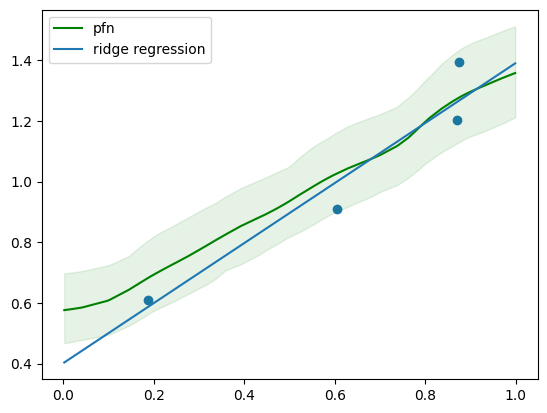

In [14]:
(xs, ys), num_training_points = dl.get_batch()

batch_index = 3
num_training_points = 4 # this is the trainset_size

xs_train = xs[batch_index, :num_training_points]
ys_train = ys[batch_index, :num_training_points]
xs_test = xs[batch_index, num_training_points:]

with torch.no_grad():
    logits = model(xs.to(device), ys.unsqueeze(-1).to(device), num_training_points)

# predicted means from a bar distribution
test_logits = logits[batch_index, num_training_points:].cpu()
pred_means = compute_mean(test_logits, bucket_limits.cpu())
pred_confs = compute_quantile(test_logits, bucket_limits.cpu())

# plot pfn
plt.scatter(xs_train[..., 0], ys_train)
order_test_x = xs_test[..., 0].argsort()
plt.plot(xs_test[order_test_x, 0], pred_means[order_test_x], color='green', label='pfn')
plt.fill_between(xs_test[order_test_x, 0], pred_confs[order_test_x, 0], pred_confs[order_test_x, 1], alpha=0.1, color='green')

ridge_model = sklearn.linear_model.Ridge(alpha=(hyperparameters['output_noise']/hyperparameters['variance_weights'])**2)
ridge_model.fit(xs_train, ys_train)
plt.plot(xs_test[order_test_x, 0], ridge_model.predict(xs_test[order_test_x]), label='ridge regression')
plt.legend()
# plt.plot();

**Visualizing Riemann Distribution**

<BarContainer object of 100 artists>

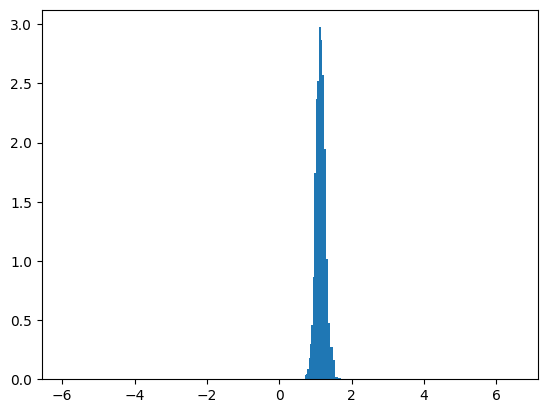

In [15]:
idx = 10
probs_of_first_pred = logits[batch_index, order_test_x[idx]].softmax(-1).detach().cpu().numpy()

borders = bucket_limits.cpu()
widths = borders[1:] - borders[:-1]

density_of_first_pred = probs_of_first_pred / widths

plt.bar(borders[:-1].tolist(), density_of_first_pred.tolist(), width=widths, align='edge')